In [1]:
PP[u_, v_, A_, Q_] := u^2((1-u)(u^2+A^2)-Q*u*v);
QQ[u_, v_, A_, B_] := B(u-v)(u^2+A^2)v;

-Graphics-
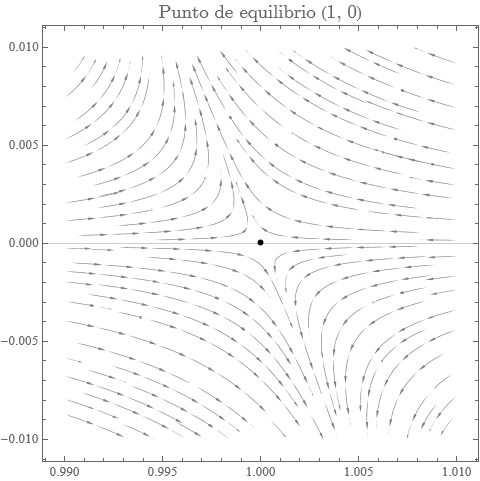

In [28]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{0.00001, 2}]; Q = RandomReal[{0.00001, 2}];
equnocero = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0.99, 1.01}, {v, -0.01, 0.01},
  Epilog -> {PointSize[Medium], Point[{1, 0}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (1, 0)", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [30]:
(* Export["puntoDeEquilibrio(1,0).pdf", equnocero] *)

puntoDeEquilibrio(1,0).pdf

-Graphics-
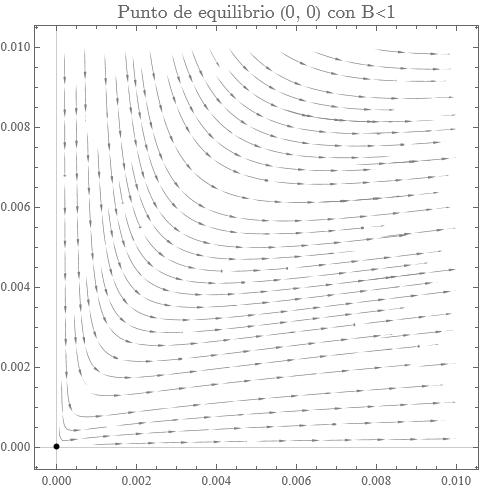

In [31]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{0.00001, 0.5}]; Q = RandomReal[{0.00001, 2}];
eqcero = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 0.01}, {v, 0, 0.01},
  Epilog -> {PointSize[Medium], Point[{0, 0}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (0, 0) con B<1", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [33]:
(* Export["puntoDeEquilibrio(0,0)conBmenor1.pdf", eqcero] *)

puntoDeEquilibrio(0,0)conBmenor1.pdf

-Graphics-
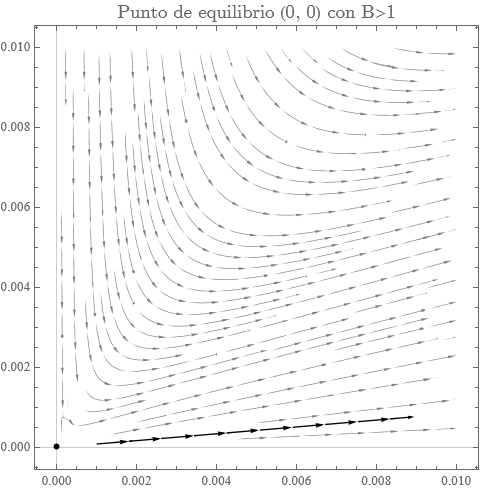

In [380]:
A = RandomReal[{0.00001, 0.99999}]; B = RandomReal[{1.00001, 2}]; Q = RandomReal[{0.00001, 2}];
x = 0.001;
y = (B-1)*x/B;

eqceroconSepar = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 0.01}, {v, 0, 0.01},
  Epilog -> {PointSize[Medium], Point[{0, 0}]},
  StreamPoints -> {{{{x, y}, Black}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style["Punto de equilibrio (0, 0) con B>1", 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
]

In [56]:
(* Export["puntoDeEquilibrio(0,0)conBmayor1.pdf", eqceroconSepar] *)

puntoDeEquilibrio(0,0)conBmayor1.pdf

0.195221
{0.0145886, 2.61239}
{0.000844912 + 0.00445193 I, 0.000844912 - 0.00445193 I}
{0.00168982, 0.00168982}
{0.00304765, 0.000468477}
            -19                            -19
{-4.26124 10    + 0.00618156 I, -4.26124 10    - 0.00618156 I}
{-0.0113064 + 0.0121219 I, -0.0113064 - 0.0121219 I}
                        -10                           -10
{-0.0226128 + 3.29272 10    I, -0.0226128 - 3.29272 10    I}
{-0.0142233, -0.0497124}
-Graphics-   -Graphics-     -Graphics-

-Graphics-   SpanFromLeft

-Graphics-   -Graphics-     -Graphics-
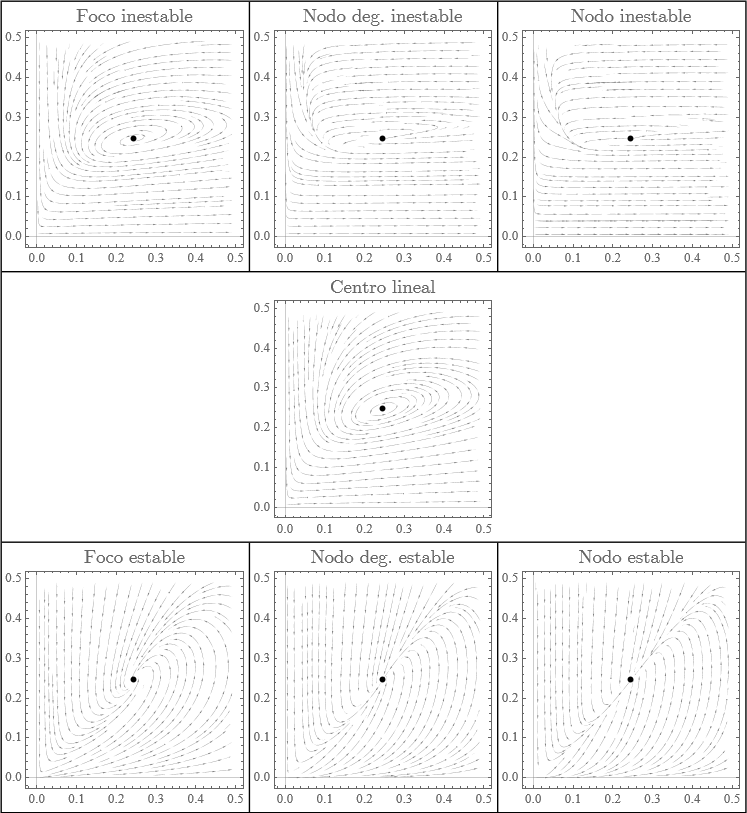

In [421]:
Clear[B]
H = RandomReal[{0.00001, 0.49999}];
maxA = H * Sqrt[1 - 2*H];
A = RandomReal[{0.00001, maxA - 0.00001}]; 
Q = (1 - H)(A^2 + H^2)/H^2;

Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

trA[B_] := -H(B(A^2 + H^2) + H^2(2H - 1) + A^2);
detA[B_] :=  B H^2 (A^2 + H^2)(H^3 + A^2(2 - H));
Delta[B_] := trA[B]^2 - 4 detA[B];

BDeltazero = B /. NSolve[Delta[B] == 0 && B > 0, B, Reals]

retrato[valB_, titulo_] := StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, valB]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart",
  PlotLabel -> Style[titulo, 
   FontFamily -> "CMU Serif", 
   FontSize -> 14
  ]
];
vp[valB_] := {(trA[valB] + Sqrt[Delta[valB]])/2, (trA[valB] - Sqrt[Delta[valB]])/2}; 

vp[(BDeltazero[[1]] + Bc)/2]
vp[BDeltazero[[1]]]
vp[BDeltazero[[1]]/2]

vp[Bc]

vp[(Bc + BDeltazero[[2]])/2]
vp[BDeltazero[[2]]]
vp[BDeltazero[[2]] + 1]

eqHH = Grid[{
  {retrato[(BDeltazero[[1]] + Bc)/2,  "Foco inestable"],
   retrato[BDeltazero[[1]], "Nodo deg. inestable"],
   retrato[BDeltazero[[1]]/2,  "Nodo inestable"]},
  {retrato[Bc, "Centro lineal"], SpanFromLeft},
  {retrato[(Bc + BDeltazero[[2]])/2,   "Foco estable"],
   retrato[BDeltazero[[2]], "Nodo deg. estable"],
   retrato[BDeltazero[[2]] + 1,   "Nodo estable"]}
}, Frame -> All]

In [441]:
Export["puntoDeEquilibrio(H,H).pdf", eqHH]

puntoDeEquilibrio(H,H).pdf

0.0589
1.59278
0.109508
-Graphics-
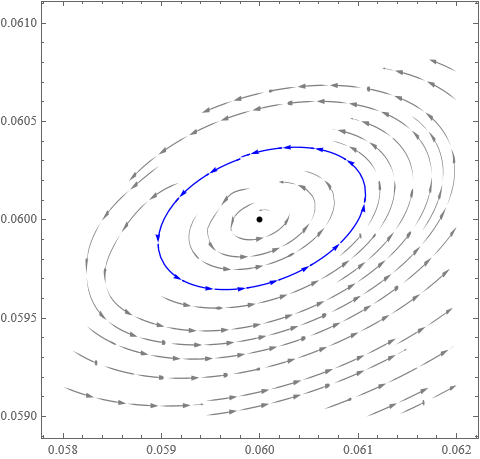

In [188]:
A = 0.05; H = 0.06;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfsub = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0.058, 0.062}, {v, 0.059, 0.061},
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  StreamPoints -> {{(*{{0.1, 0.05458}, Black}, {{0.08, 0.07}, Black},*) {{0.061, 0.06}, Blue}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [52]:
CopyToClipboard[QQ[x, y, A, Bc]]

In [23]:
Export["HopfSubCentrolineal.pdf", hopfsub]

HopfSubCentrolineal.pdf

-8
1.18241 10
0.367609
-Graphics-
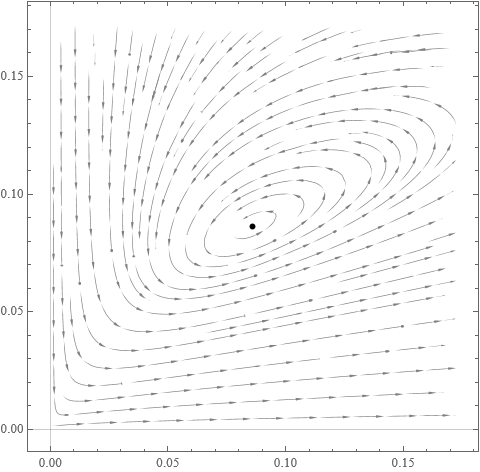

In [248]:
A = 0.05; H = 0.0862168;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfdeg = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{{H, H}}]},
  (*StreamPoints -> {{{{0.289, 0.289}, Black}, {{0.32, 0.32}, Gray}, {{0.35, 0.35}, Gray}, {{0.2, 0.4}, Gray}, Automatic}},*)
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [ ]:
Export["HopfDegCentrolineal.pdf", hopfdeg]

-0.0250864
0.609375
0.181538
-Graphics-
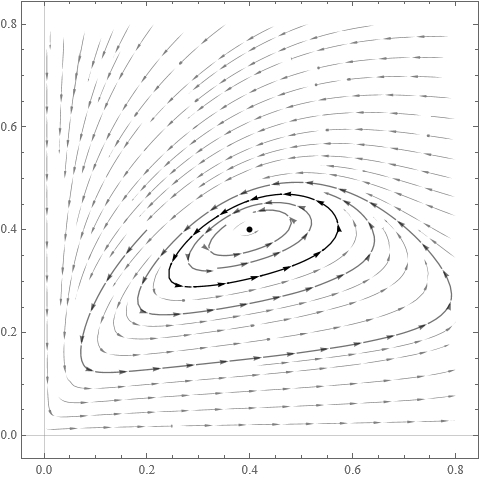

In [109]:
A = 0.05; H = 0.4;
L1 = (A^2*(-1 + H)*H*(-4*A^2*H^3 + (-3 + H)*H^5 + A^4*(4 + 3*(-3 + H)*H)))/(2*(A^2 + H^2)*(-(A^2*(-2 + H)) + H^3)*(A^2 + H^2*(-1 + 2*H)))
Q = (1 - H)(A^2 + H^2)/H^2
Bc = (H^2(1 - 2H) - A^2)/(A^2 + H^2)

hopfsuper = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, Bc]}, {u, 0, 2*H}, {v, 0, 2*H},
  Epilog -> {PointSize[Medium], Point[{{H, H}}]},
  StreamPoints -> {{{{0.289, 0.289}, Black}, {{0.32, 0.32}, Directive[Opacity[.55], Black]}, {{0.35, 0.35}, Directive[Opacity[.55], Black]}, {{0.2, 0.4}, Directive[Opacity[.55], Black]}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]

In [103]:
Export["HopfSuperCentrolineal.pdf", hopfsuper]

HopfSuperCentrolineal.pdf

-Graphics-
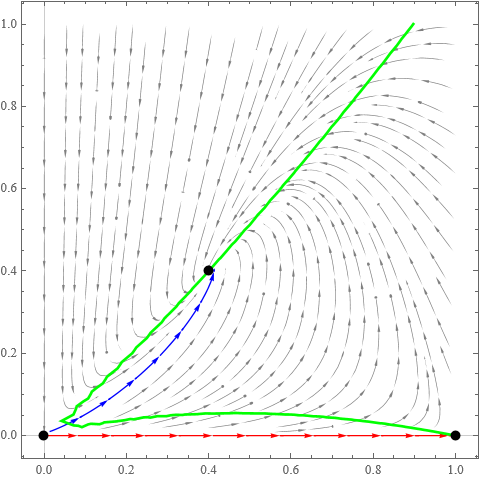

In [270]:
B = 1.5; m = (B-1)/B;

plot = StreamPlot[{u^2((1-u)(u^2+A^2)-Q*u*v), B(u-v)(u^2+A^2)v}, {u, 0, 1}, {v, 0, 1},
  Epilog -> {PointSize[Large], Point[{{0, 0}, {1, 0}, {H, H}}]},
  StreamPoints -> {{{{0.5, 0}, Red}, {{0.06, 0.03}, Blue}, Automatic}},
  StreamColorFunction -> None,
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
];

iso = ContourPlot[QQ[u, v, A, B] - m*PP[u, v, A, Q] == 0, {u, 0, 1}, {v, 0, 1}, 
   ContourStyle -> {Thick, Green}];

Show[plot, iso]

-21
-1.69407 10
-Graphics-
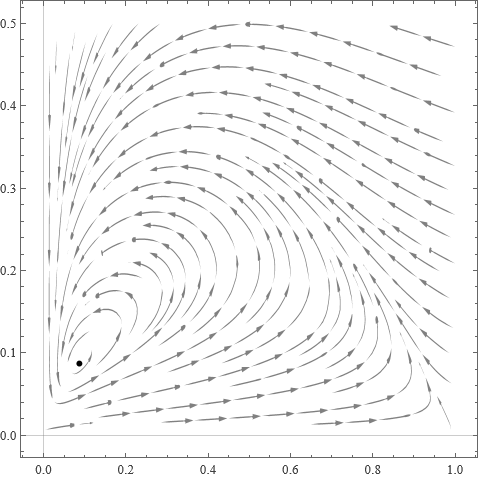

In [16]:
Clear[A, B, H, Q, u, v]; A = 0.05059103559978497; B = 0.36435231308468385; Q = 1.222017313071541;

H = 0.08696600618632838 ;

primerLyapunov = (3H(3-H)-4)A^4 + 4H^3A^2 + (3-H)H^5

hopfGeneral = StreamPlot[{PP[u, v, A, Q], QQ[u, v, A, B]}, {u, 0, 1}, {v, 0, .5},
  StreamColorFunction -> None,
  Epilog -> {PointSize[Medium], Point[{H, H}]},
  PlotTheme -> "Scientific",
  StreamStyle -> Gray,
  StreamMarkers -> "PinDart"
]


In [20]:
Export["HopfGeneralCentrolineal.pdf", hopfGeneral]

HopfGeneralCentrolineal.pdf